In [2]:
# Importing libraries for data handling, visualization, and deep learning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import glob 
from skimage.io import imread
import cv2
from PIL import Image
from skimage.transform import resize
import itertools
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
from keras.metrics import categorical_crossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from tensorflow.keras.models import save_model

In [3]:
# Loading the dataset
df = pd.read_csv('/kaggle/input/facial-emotion-recognition/emotions.csv')
df

,set_id,gender,age,country
0,0,FEMALE,36,RU
1,1,FEMALE,37,RU
2,2,FEMALE,36,RU
3,3,MALE,29,RU
4,4,FEMALE,43,RU
5,5,MALE,49,RU
6,6,FEMALE,38,RU
7,7,MALE,19,PH
8,8,FEMALE,29,RU
9,9,FEMALE,32,RU


In [4]:
# Loading image paths
images = glob.glob('/kaggle/input/facial-emotion-recognition/images/*/*.jpg')
print(len(images)) # Total number of images
print(images[0]) # Example path

152
/kaggle/input/facial-emotion-recognition/images/7/Disgust.jpg


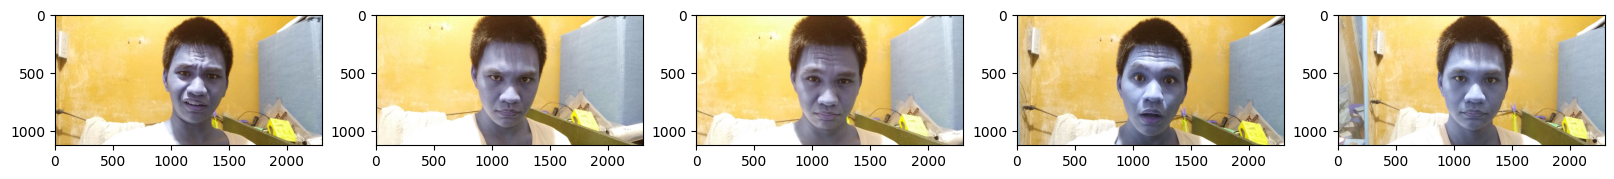

In [5]:
# Displaying some sample images
fig, axes = plt.subplots(1, 5, figsize=(20, 10))  
for i in range(5):
    img = cv2.imread(images[i])
    axes[i].imshow(img)      
plt.show()

In [6]:
# Creating a DataFrame for image paths and their respective emotions
image_data = pd.DataFrame(index=np.arange(0, len(images)), columns=['path', 'emotion'])
for i in range(len(images)):
    image_data.loc[i, 'path'] = images[i]
    image_data.loc[i, 'emotion'] = images[i][50:].replace(images[i][-4:], '')

In [7]:
image_data

,path,emotion
0,/kaggle/input/facial-emotion-recognition/image...,Disgust
1,/kaggle/input/facial-emotion-recognition/image...,Anger
2,/kaggle/input/facial-emotion-recognition/image...,Sad
3,/kaggle/input/facial-emotion-recognition/image...,Surprised
4,/kaggle/input/facial-emotion-recognition/image...,Neutral
...,...,...
147,/kaggle/input/facial-emotion-recognition/image...,/Surprised
148,/kaggle/input/facial-emotion-recognition/image...,/Neutral
149,/kaggle/input/facial-emotion-recognition/image...,/Happy
150,/kaggle/input/facial-emotion-recognition/image...,/Fear


In [8]:
# Standardizing the emotion column values by removing unnecessary prefixes to ensure consistency in emotion labels.
image_data['emotion'] = image_data['emotion'].replace('/Surprised', 'Surprised')
image_data['emotion'] = image_data['emotion'].replace('/Happy', 'Happy')
image_data['emotion'] = image_data['emotion'].replace('/Sad', 'Sad')
image_data['emotion'] = image_data['emotion'].replace('/Anger', 'Anger')
image_data['emotion'] = image_data['emotion'].replace('/Neutral', 'Neutral')
image_data['emotion'] = image_data['emotion'].replace('/Fear', 'Fear')
image_data['emotion'] = image_data['emotion'].replace('/Contempt', 'Contempt')
image_data['emotion'] = image_data['emotion'].replace('/Disgust', 'Disgust')

In [10]:
# Encoding the emotion labels as integers using LabelEncoder
label_encoder = LabelEncoder()
image_data['emotion'] = label_encoder.fit_transform(image_data['emotion'])
image_data

,path,emotion
0,/kaggle/input/facial-emotion-recognition/image...,2
1,/kaggle/input/facial-emotion-recognition/image...,0
2,/kaggle/input/facial-emotion-recognition/image...,6
3,/kaggle/input/facial-emotion-recognition/image...,7
4,/kaggle/input/facial-emotion-recognition/image...,5
...,...,...
147,/kaggle/input/facial-emotion-recognition/image...,7
148,/kaggle/input/facial-emotion-recognition/image...,5
149,/kaggle/input/facial-emotion-recognition/image...,4
150,/kaggle/input/facial-emotion-recognition/image...,3


In [11]:
# Loading and resizing images to 224x224 pixels and preparing feature (X) and label (y) arrays
X = []
y = []
for feature, label in image_data.values:
    image = cv2.imread(feature)
    image = cv2.resize(image, (224, 224), interpolation = cv2.INTER_LINEAR)
    X.append(image)
    y.append(label)
X = np.array(X)
y = np.array(y)

In [12]:
# Print shape of input data (X) and output data (y)
print(f'Shape of X: {X.shape}')
print(f'Shape of y: {y.shape}')

Shape of X: (152, 224, 224, 3)
Shape of y: (152,)


In [13]:
# Data augmentation using ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=30,        
    width_shift_range=0.2,    
    height_shift_range=0.2,   
    shear_range=0.2,          
    zoom_range=0.2,           
    horizontal_flip=True,     
    fill_mode='nearest'       
)

In [14]:
# Applying augmentation to images
augmented_X = []
augmented_y = []
for i in range(len(X)):
    img = X[i].reshape((1, *X[i].shape))  
    label = y[i]
    for _ in range(50):  
        augmented = next(datagen.flow(img, batch_size=1))
        augmented_X.append(augmented[0])  
        augmented_y.append(label)        
augmented_X = np.array(augmented_X)
augmented_y = np.array(augmented_y)

In [15]:
# Combining original and augmented data
X = np.concatenate([X, augmented_X], axis=0)
y = np.concatenate([y, augmented_y], axis=0)

In [16]:
# Print shape of input data (X) and output data (y) after augmentation
print(X.shape)  
print(y.shape)

(7752, 224, 224, 3)
(7752,)


In [17]:
# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [18]:
print(f'Length of Training Data: {len(X_train)}')
print(f'Length of Testing Data: {len(X_test)}')

Length of Training Data: 6201
Length of Testing Data: 1551


In [19]:
y_train = to_categorical(y_train, num_classes = 8)
y_test = to_categorical(y_test, num_classes = 8)

In [20]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks
early_stopping = EarlyStopping(monitor='val_accuracy', patience=10, mode='max', verbose=1, restore_best_weights=True)
lr_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience=3, mode='max', verbose=1, factor=0.5, min_lr=0.0001)

# Path to uploaded weight file
weight_path = "/kaggle/input/netxmpl/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5"

# Build base model from local weights
base_model = ResNet50(
    weights=weight_path,
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # Freeze layers

# Final model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(8, activation='softmax')
])

2025-12-12 09:45:08.681766: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [21]:
# Compiling the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,770,184 (94.49 MB)

 Trainable params: 1,182,472 (4.51 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [22]:
# Training the model
history = model.fit(
    X_train, y_train, batch_size=20, validation_data=(X_test, y_test), epochs=25, callbacks=[early_stopping, lr_reduction]
)

Epoch 1/25
311/311 ━━━━━━━━━━━━━━━━━━━━ 650s 2s/step - accuracy: 0.1806 - loss: 2.1695 - val_accuracy: 0.3952 - val_loss: 1.6156 - learning_rate: 0.0010
Epoch 2/25
311/311 ━━━━━━━━━━━━━━━━━━━━ 626s 2s/step - accuracy: 0.4204 - loss: 1.5040 - val_accuracy: 0.5919 - val_loss: 1.0639 - learning_rate: 0.0010
Epoch 3/25
311/311 ━━━━━━━━━━━━━━━━━━━━ 636s 2s/step - accuracy: 0.6461 - loss: 0.9547 - val_accuracy: 0.7221 - val_loss: 0.7903 - learning_rate: 0.0010
Epoch 4/25
311/311 ━━━━━━━━━━━━━━━━━━━━ 642s 2s/step - accuracy: 0.7643 - loss: 0.6333 - val_accuracy: 0.6776 - val_loss: 0.8751 - learning_rate: 0.0010
Epoch 5/25
311/311 ━━━━━━━━━━━━━━━━━━━━ 624s 2s/step - accuracy: 0.8394 - loss: 0.4653 - val_accuracy: 0.7589 - val_loss: 0.6747 - learning_rate: 0.0010
Epoch 6/25
311/311 ━━━━━━━━━━━━━━━━━━━━ 630s 2s/step - accuracy: 0.8650 - loss: 0.4042 - val_accuracy: 0.7827 - val_loss: 0.6227 - learning_rate: 0.0010
Epoch 7/25
311/311 ━━━━━━━━━━━━━━━━━━━━ 629s 2s/step - accuracy: 0.9149 - loss: 0.

In [23]:
# Evaluating the model
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)
print("Loss:", loss)

49/49 ━━━━━━━━━━━━━━━━━━━━ 130s 3s/step - accuracy: 0.9507 - loss: 0.1552
Test Accuracy: 0.9471308588981628
Loss: 0.1682763397693634


In [24]:
# Classification report
y_pred = model.predict(X_test)
y_test = np.argmax(y_test, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)
print(classification_report(y_test, y_pred_classes))

49/49 ━━━━━━━━━━━━━━━━━━━━ 135s 3s/step
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       206
           1       0.97      0.93      0.95       215
           2       0.98      0.96      0.97       203
           3       0.94      0.98      0.96       176
           4       0.90      0.95      0.93       179
           5       0.96      0.94      0.95       184
           6       0.94      0.94      0.94       194
           7       0.95      0.97      0.96       194

    accuracy                           0.95      1551
   macro avg       0.95      0.95      0.95      1551
weighted avg       0.95      0.95      0.95      1551



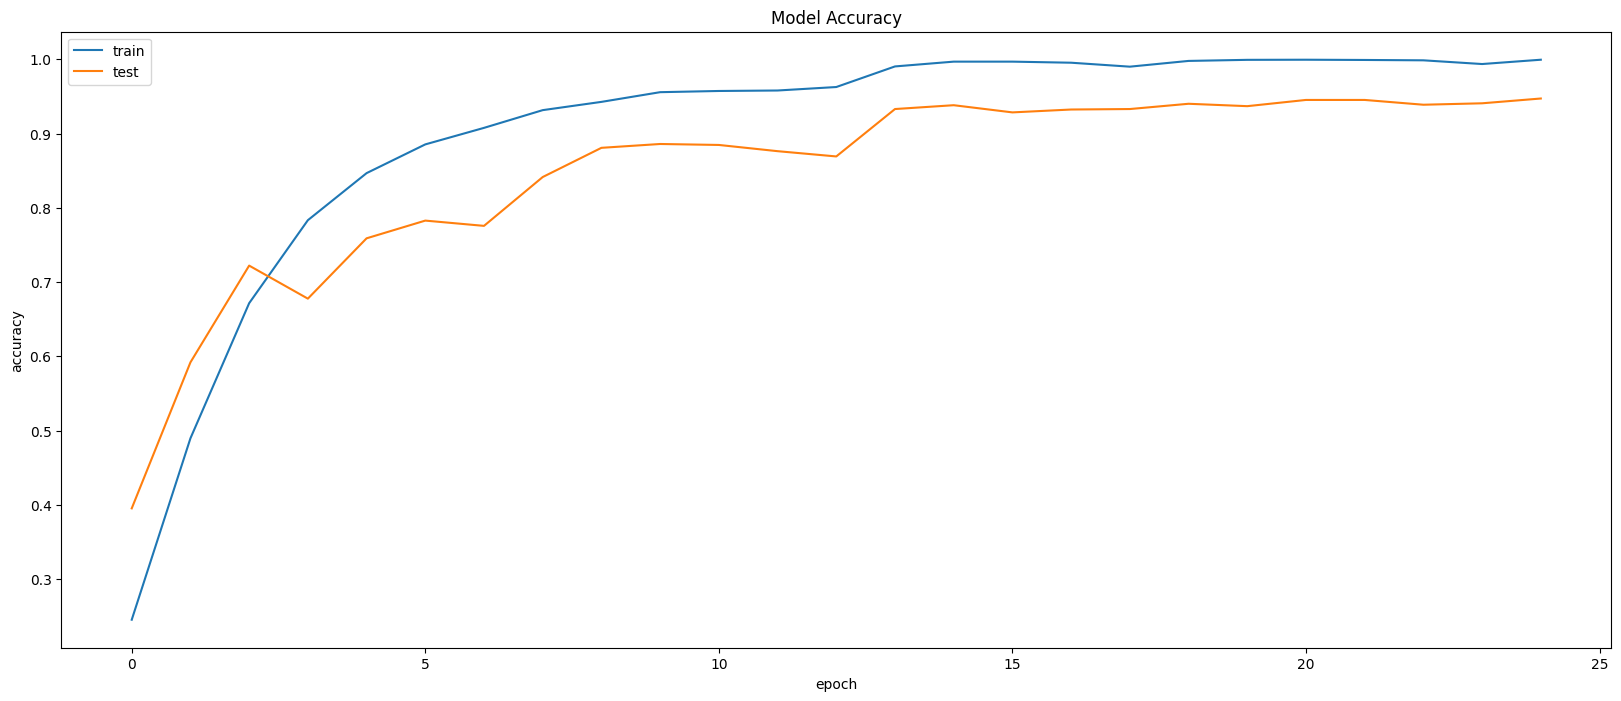

In [26]:
plt.figure(figsize=(20, 8))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()


In [28]:
model.save('emotion_model.keras')